En este notebook, realizaremos los trabajos necesarios con respecto a nuestras variables y comenzaremos a aplicar el modelo de regresión logistica, aunque el mismo sigue en proceso de evaluación y no ha sido finalizado aún.


In [ ]:
# Importamos librerias a utilizar
from scipy.io import arff
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import Pipeline
from Preprocessing import DataPreProcessor, TargetEncoder

In [6]:
#Cargamos el dataset y lo transformamos en un DataFrame de pandas para poder manipularlo de manera más sencilla.

data, meta = arff.loadarff("/Users/Camila/Desktop/datasets/dataset_31_credit-g.arff")
df = pd.DataFrame(data)

#Decodificamos los strings que provienen del archivo ARFF para que sean legibles y consistentes en el DataFrame.
for column in df.select_dtypes([object]).columns:
    df[column] = df[column].str.decode('utf-8')

#Transformamos el tipo de dato objeto a categorico
columnas = df.select_dtypes(['object']).columns
df[columnas] = df[columnas].astype('category') 

### Dividimos los datos en entrenamiento y test, antes de realizar transformaciones, para evitar data leakage 

In [71]:
X = df.drop(columns=['class']) 
y = df['class']

#Creamos las columnas que luego se transformarán
columnas_categoricas = [col for col in X.select_dtypes(['category']).columns if X[col].nunique() > 2]
columnas_binarias = [col for col in X.select_dtypes(['category']).columns if X[col].nunique() == 2]
columnas_numericas = X.select_dtypes(include=['float','int']).columns.to_list()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)



### Transformamos nuestras variables

In [72]:
#Transformamos variable objetivo
target_encoder = TargetEncoder()
y_train = target_encoder.transform(y_train)
y_test = target_encoder.transform(y_test)

#transformamos variables de entrenamiento
procesador = DataPreProcessor(columnas_categoricas,columnas_numericas,columnas_binarias)
procesador.fit(X_train)
X_train = procesador.transform(X_train)
X_test = procesador.transform(X_test)


In [12]:
X_train.shape

(800, 48)

Chequeamos el rango de nuestra matriz

In [13]:
print(np.linalg.matrix_rank(X_train))
print(X_train.shape)

48
(800, 48)


In [9]:
(X_train.nunique() == 1).sum()

np.int64(0)

### Creamos el modelo 
Siguiendo con la condición de : Es 5 veces peor clasificar a un usuario como bueno cuando es malo, que clasificarlo como malo cuando es bueno. Definimos pesos para la Regresion. Esto hará que el modelo penalice más clasificar a un mal usuario como bueno, que un buen usuario como malo. 

In [51]:
pesos = {0 : 5, 1: 1}

In [ ]:
modelo = LogisticRegression(
    random_state=42,
    penalty = None,
    class_weight=pesos )


modelo.fit(X_train, y_train)
pred = modelo.predict(X_test)
print(classification_report(y_test,pred))


              precision    recall  f1-score   support

           0       0.43      0.88      0.58        60
           1       0.91      0.50      0.65       140

    accuracy                           0.61       200
   macro avg       0.67      0.69      0.61       200
weighted avg       0.77      0.61      0.63       200



 Sin penalty
                precision    recall  f1-score   support

           0       0.40      0.95      0.57        60
           1       0.95      0.40      0.56       140

    accuracy                           0.56       200
   macro avg       0.68      0.68      0.56       200
weighted avg       0.79      0.56      0.56       200

con penalty = l2
                precision    recall  f1-score   support

           0       0.40      0.95      0.56        60
           1       0.95      0.39      0.55       140

    accuracy                           0.56       200
   macro avg       0.67      0.67      0.55       200
weighted avg       0.78      0.56      0.55       200


Matriz de Confusión Numérica:
[[57  3]
 [84 56]]


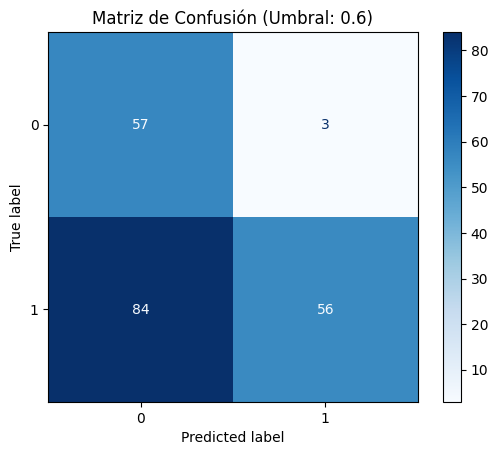

In [74]:
# 1. Calcular la matriz de confusión numérica
# (y_test son los valores reales, predicciones_personalizadas son las del umbral)
cm = confusion_matrix(y_test, pred)

print("Matriz de Confusión Numérica:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=modelo.classes_ # Muestra tus etiquetas originales (0:bad y 1:good)
)

disp.plot(cmap=plt.cm.Blues)

plt.title(f"Matriz de Confusión (Umbral: {umbral_personalizado})")
plt.show()

In [80]:
#Probamos este metodo para obtener el umbral ideal
from sklearn.model_selection import TunedThresholdClassifierCV

# Creas tu modelo base
log_reg = LogisticRegression()

model_con_umbral = TunedThresholdClassifierCV(estimator=log_reg, scoring='accuracy')

# Al hacer fit, entrena la regresión Y encuentra el umbral ideal
model_con_umbral.fit(X_train, y_train)

# Al hacer predict, ya aplica automáticamente ese nuevo umbral optimizado
predicciones = model_con_umbral.predict(X_test)
print(classification_report(y_test,predicciones))

umbral_calculado = model_con_umbral.best_threshold_

print(f"El umbral óptimo calculado por el modelo es: {umbral_calculado:.4f}")




              precision    recall  f1-score   support

           0       0.48      0.48      0.48        60
           1       0.78      0.77      0.77       140

    accuracy                           0.69       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.69      0.69      0.69       200

El umbral óptimo calculado por el modelo es: 0.5519


Matriz de Confusión Numérica:
[[53  7]
 [70 70]]


Text(0.5, 1.0, 'Matriz de Confusión  0.5519)')

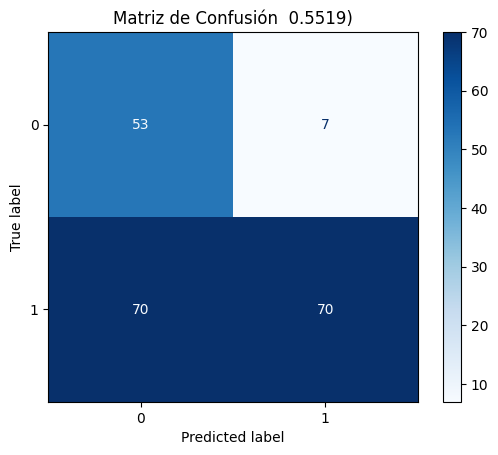

In [83]:
cm = confusion_matrix(y_test, pred)

print("Matriz de Confusión Numérica:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=model_con_umbral.classes_ # Muestra tus etiquetas originales (0:bad y 1:good)
)

disp.plot(cmap=plt.cm.Blues)

plt.title(f"Matriz de Confusión  {umbral_calculado:.4f})")

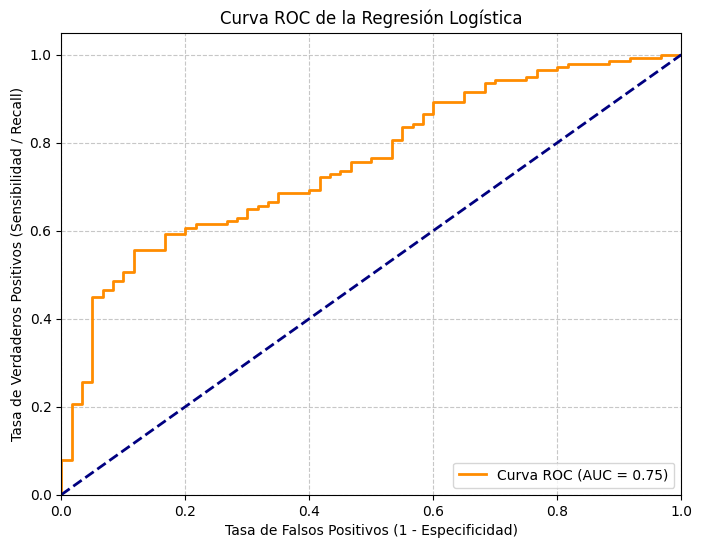

In [65]:
# 1. Calcular los ratios de falsos positivos (fpr) y verdaderos positivos (tpr)
fpr, tpr, thresholds = roc_curve(y_test, probabilidades_clase_1)

# 2. Calcular el área bajo la curva (AUC)
roc_auc = auc(fpr, tpr)

# 3. Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')

# Graficar la línea diagonal de referencia (un modelo aleatorio)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Configuración de etiquetas y límites del gráfico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad / Recall)')
plt.title('Curva ROC de la Regresión Logística')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()


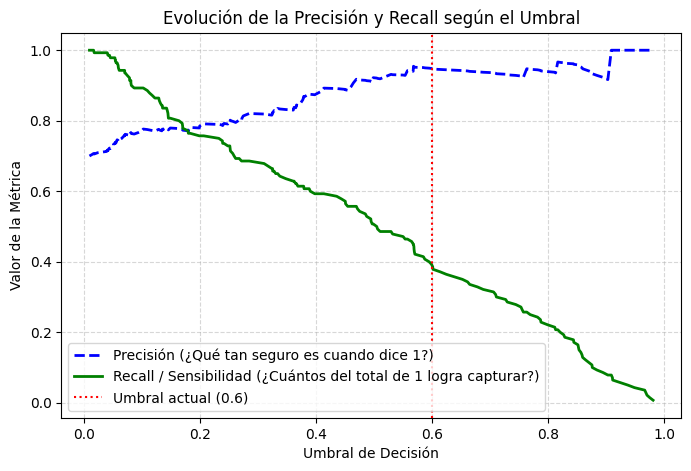

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# 1. Calcular precisión y recall para todos los umbrales posibles
precisions, recalls, thresholds = precision_recall_curve(y_test, probabilidades_clase_1)

# 2. Graficar cómo cambia la precisión según el umbral
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precisión (¿Qué tan seguro es cuando dice 1?)', lw=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall / Sensibilidad (¿Cuántos del total de 1 logra capturar?)', lw=2)

# Dibujar una línea en tu umbral actual (0.6)
plt.axvline(x=0.6, color='red', linestyle=':', label='Umbral actual (0.6)')

plt.xlabel('Umbral de Decisión')
plt.ylabel('Valor de la Métrica')
plt.title('Evolución de la Precisión y Recall según el Umbral')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


### Ver los parámetros de nuestra regresión

In [66]:
#Extraemos el modelo de regresión logística entrenado desde el pipeline


# Para obtener el intercepto
interseccion = modelo.intercept_[0]

#Obtener los parámetros 
coeficientes = modelo.coef_[0]

print(f"Intersección (Intercept / b0): {interseccion}\n")

# 4. Mostrar los coeficientes junto al nombre de cada variable
# Nota: Reemplaza 'nombre_de_las_columnas' por la lista de nombres que generó tu 'preprocessor'
try:
    nombres_columnas = modelo.get_feature_names_out()
    print("Coeficientes por variable:")
    for col, coef in zip(nombres_columnas, coeficientes):
        print(f" - {col}: {coef:.4f}")
except AttributeError:
    print("Coeficientes (ordenados según entraron al clasificador):")
    print(coeficientes)


Intersección (Intercept / b0): -1.1102483534082235

Coeficientes (ordenados según entraron al clasificador):
[-3.65539958e-01  3.41664590e-01  1.49725596e+00  1.27180709e+00
  2.95747325e-01  3.77084725e-01 -1.71512823e-01 -1.76838504e-01
 -1.20089063e+00  6.53219623e-02 -7.56778511e-01  4.48179572e-02
  2.96639667e-01 -9.16949644e-01  9.70366214e-01  1.84288787e+00
 -5.12746998e-01 -6.34350017e-01  9.00335333e-01  1.33855434e-01
  5.92023348e-01 -8.82211339e-02 -2.56904162e-02 -2.66468841e-01
 -2.76553981e-01  7.48594527e-02  3.79509172e-01  1.67376273e+00
  4.46104053e-01 -2.68896845e-01 -4.81270166e-01  1.20888361e-01
  8.78678496e-01 -4.71202813e-02  3.91460119e-01 -5.42936371e-02
 -2.85836384e-01 -4.86292294e-04 -2.72563082e-01 -2.88433580e-01
 -4.20607936e-01 -3.07738547e-01 -9.51281443e-03  2.80859571e-01
 -8.24530034e-02  3.22073227e-02  3.51948427e-01 -1.58552627e+00]


In [ ]:
0.38350014  0.28927563  1.43303744  1.09385101  0.15228942  0.24188017
 -0.27846588 -0.10776557 -1.05526161  0.04920953 -0.7379934  -0.02068934
  0.29671722 -0.7425709   0.63361649  1.69574778 -0.43828186 -0.57500403
  0.75132003  0.17868247  0.58926006 -0.09612708 -0.00698797 -0.25781167
 -0.24272588  0.08936933  0.36614245  1.36479834  0.28232995 -0.24038335
 -0.47162874  0.12945993  0.8511931  -0.05826901  0.33786654 -0.09391089
 -0.24470624 -0.04602561 -0.2236988  -0.29224274 -0.4012232  -0.30590396
 -0.00949686  0.27477212 -0.07313387  0.02686136  0.35337861 -1.32180357]

Conclusiones hasta ahora:
El modelo está sesgado en predecir la clase 0, es decir, aproximadamente la mitad de las veces clasificó las observaciones como créditos riesgosos. Esto puede comprenderse debido a los pesos que se le han asignado al modelo. Recordemos que se había establecido que "es 5 veces peor clasificar a un usuario como bueno cuando es malo, que clasificarlo como malo cuando es bueno", lo cual obligará al modelo a aprender y penalizar mayormente dichas equivocaciones.

Debemos continuar optimizando el modelo para obtener mejores resultados, para ello debemos definir el umbral de decisión que optimice el modelo. (continuar)